In [1]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

In [15]:

def load_cell_images(cell_images_dir):
  
    cell_images = {}
    for filename in tqdm(os.listdir(cell_images_dir), desc="Loading cell images"):
        if filename.endswith('.npy'):
            cell_id = int(filename.split('_')[1].split('.')[0])  # 从文件名中提取cell_id
            image_path = os.path.join(cell_images_dir, filename)
            cell_images[cell_id] = np.load(image_path)
    return cell_images

def match_cells_with_images(cell_boundaries_path, cell_images):
   
    cell_boundaries = pd.read_csv(cell_boundaries_path)
    
    cell_boundaries['image'] = cell_boundaries['cell_id'].map(cell_images)
    
    return cell_boundaries


cell_images_dir = './'
cell_boundaries_path = 'data/Xenium/breast_cancer/outs/cell_boundaries.csv.gz'


cell_images = load_cell_images(cell_images_dir)


matched_data = match_cells_with_images(cell_boundaries_path, cell_images)



Loading cell images: 100%|██████████| 46/46 [00:00<00:00, 4242.35it/s]


In [16]:

first_cell_image = matched_data.iloc[0]['image']
print(f"First cell image shape: {first_cell_image.shape}")

First cell image shape: (1, 1, 3)


In [17]:
image = cv2.cvtColor(first_cell_image, cv2.COLOR_RGB2BGR)

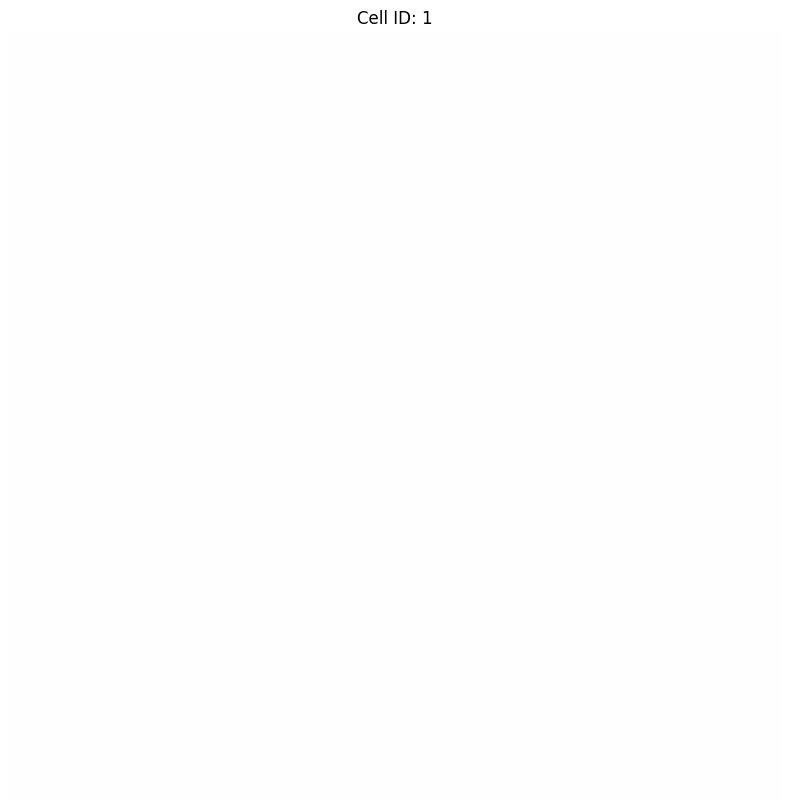

In [18]:
plt.figure(figsize=(10, 10))
plt.imshow(first_cell_image)
plt.title(f"Cell ID: {matched_data.iloc[0]['cell_id']}")
plt.axis('off') 
plt.show()

In [17]:
cv2.imshow('HE Image', image)

: 

: 

: 